 # Библиотеки

In [349]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

# Система дифференциальных уравнений

In [350]:
def model(t, y, params): 
    '''система уравнений, где 
    d     --    полунасыщение, 
    beta  --    избегание,
    r     --    врожденная скорость роста (сколько потомства дает клетка в ед вр)
    k     --    емкость среды (max P)
    alfa  --    конкурентное воздействие (насколько 1 вид забирает возможность размножаться у второго)
    w     --    скорость поедания (сколько Р съедает 1z за ед вр)
    c     --    коэффициент вымирания z
    y = [p1, p2, z] для сигнатуры solutionve_ipv'''
    p1, p2, z = y
    r1, r2, k1, k2, alpha1, alpha2, w1, w2, d1, d2, beta, c = params

    #система уравнений
    dP1dt = r1*p1*(1 - (alpha1*p2 + p1)/k1) - (w1*p1*z)/(d1+p1)
    dP2dt = r2*p2*(1 - (alpha2*p1 + p2)/k2) - (w2*p2*z)/(d2+p2+ beta*p1)
    dZdt = (w1*p1*z)/(d1+p1) - (w2*p2*z)/(d2+p2+beta*p1) - c*z

    # if p1 < 0 or p2 < 0 or z < 0:
    #     raise ValueError(f"Отрицательная биомасса при t={t}: p1={p1}, p2={p2}, z={z}")

    return [dP1dt, dP2dt, dZdt]

## Численное решение системы диф уравнений

 ### Воспроизведение части статьи 3.1. Time series analysis

####      параметры для модели (из статьи)

In [351]:
#beta = [0, 5, 1000]
#t = 22
#t = 1000
# значения параметров были указаны в таблице 1 на стр.146
p1, p2, z = 0.5 , 0.5, 20   #( мг\см^3)
r1, r2    = 0.56, 0.49
alpha1    =  alpha2  =  0       # параметры неизменяемы, позволю себе это
k1, k2    = 5600, 4900
w1        =    w2    =  0.5
d1        =    d2    =  30
c         = 0.05 

Для автоматизации процесса создам сценарии, исследуемые в статье

In [352]:
scenarios = {
    # рис.2 из статьи (первые 22 дня)
    'Рис.2a (beta=0)': {
        'beta': 0,
        'y0': (0.5, 0.5, 25),
        't_max': 22,
        't_points': 500
    },
    'Рис.2b (beta=5)': {
        'beta': 5,
        'y0': (0.5, 0.5, 25),
        't_max': 22,
        't_points': 500
    },
    'Рис.2c (beta=1000)': {
        'beta': 1000,
        'y0': (0.5, 0.5, 25),
        't_max': 22,
        't_points': 500
    },
    
    # рис.3 из статьи (долгосрочная динамика и исследование влияния параметра бета)
    'Рис.3a (beta=0, y0=25)': {
        'beta': 0,
        'y0': (0.5, 0.5, 25),
        't_max': 1000,
        't_points': 20000
    },
    'Рис.3b (beta=0, y0=20)': {
        'beta': 0,
        'y0': (0.5, 0.5, 20),
        't_max': 1000,
        't_points': 20000
    },
    'Рис.3c (beta=10, y0=25)': {
        'beta': 10,
        'y0': (0.5, 0.5, 25),
        't_max': 1000,
        't_points': 20000
    },
}

In [353]:
def event_negative(t, y, *args):
    """Событие: интегрирование останавливается , если любая переменная становится отрицательной"""
    # внутри библиотеки sipy приверяется смена знака и находится корень, 
    return min(y)  

event_negative.terminal = True  
event_negative.direction = -1   

### Решние и сохранение результатов для графиков

In [354]:
# ПЕРВАЯ ПОПЫТКА, БЕЗ АВТОМАТИЗАЦИИ
# results = {}

# for b in beta:
#     params = r1, r2, k1, k2, alpha1, alpha2, w1, w2, d1, d2, b, c
#     solution = solve_ivp(
#     fun    = model,
#     t_span = (0, t),
#     y0     = [p1, p2, z],
#     method = 'RK45',
#     t_eval = np.linspace(0, t, 10000),
#     args = (params,),
#     events=event_negative
#     )
#     # проверка успешности
#     print(" при beta = ",b)
#     if solution.status == 1 and solution.t_events[0].size > 0:
#         print(f"ВНИМАНИЕ: Интегрирование остановлено при t={solution.t_events[0][0]:.3f} из-за отрицательной биомассы!")
#     print(f"Успешно: {solution.success}")
#     print(f"Причина остановки: {solution.message}")
#     print(f"Количество шагов: {len(solution.t)}")
#     results[b] = solution


In [355]:
results = {}

for name, cfg in scenarios.items():
    params = (r1, r2, k1, k2, alpha1, alpha2, w1, w2, d1, d2, cfg['beta'], c)
    solution = solve_ivp(
        fun=model,
        t_span=(0, cfg['t_max']),
        y0=cfg['y0'],
        method='RK45',
        t_eval=np.linspace(0, cfg['t_max'], cfg['t_points']),
        args=(params,),
        events=event_negative
    )
    results[name] = solution
    
    print(f"{name:}:", end=" ")
    if solution.status == 1 and solution.t_events[0].size > 0:
        print(f"ВНИМАНИЕ: Интегрирование остановлено при t={solution.t_events[0][0]:.3f} из-за отрицательной биомассы!")
    print(f"Успешно: {solution.success}")
    print(f"Причина остановки: {solution.message}")
    print(f"Количество шагов: {len(solution.t)}")
    print(f"  Финал: P1={solution.y[0][-1]:.2f}, P2={solution.y[1][-1]:.2f}, Z={solution.y[2][-1]:.2f}\n")


Рис.2a (beta=0): Успешно: True
Причина остановки: The solver successfully reached the end of the integration interval.
Количество шагов: 500
  Финал: P1=742.31, P2=13.66, Z=75.40

Рис.2b (beta=5): Успешно: True
Причина остановки: The solver successfully reached the end of the integration interval.
Количество шагов: 500
  Финал: P1=597.39, P2=824.01, Z=121.38

Рис.2c (beta=1000): Успешно: True
Причина остановки: The solver successfully reached the end of the integration interval.
Количество шагов: 500
  Финал: P1=78.53, P2=3993.81, Z=141.66

Рис.3a (beta=0, y0=25): Успешно: True
Причина остановки: The solver successfully reached the end of the integration interval.
Количество шагов: 20000
  Финал: P1=0.00, P2=0.00, Z=339.79

Рис.3b (beta=0, y0=20): Успешно: True
Причина остановки: The solver successfully reached the end of the integration interval.
Количество шагов: 20000
  Финал: P1=5598.64, P2=4900.00, Z=0.00

Рис.3c (beta=10, y0=25): Успешно: True
Причина остановки: The solver succes

### Код для графиков (временные ряды, короткий срок)

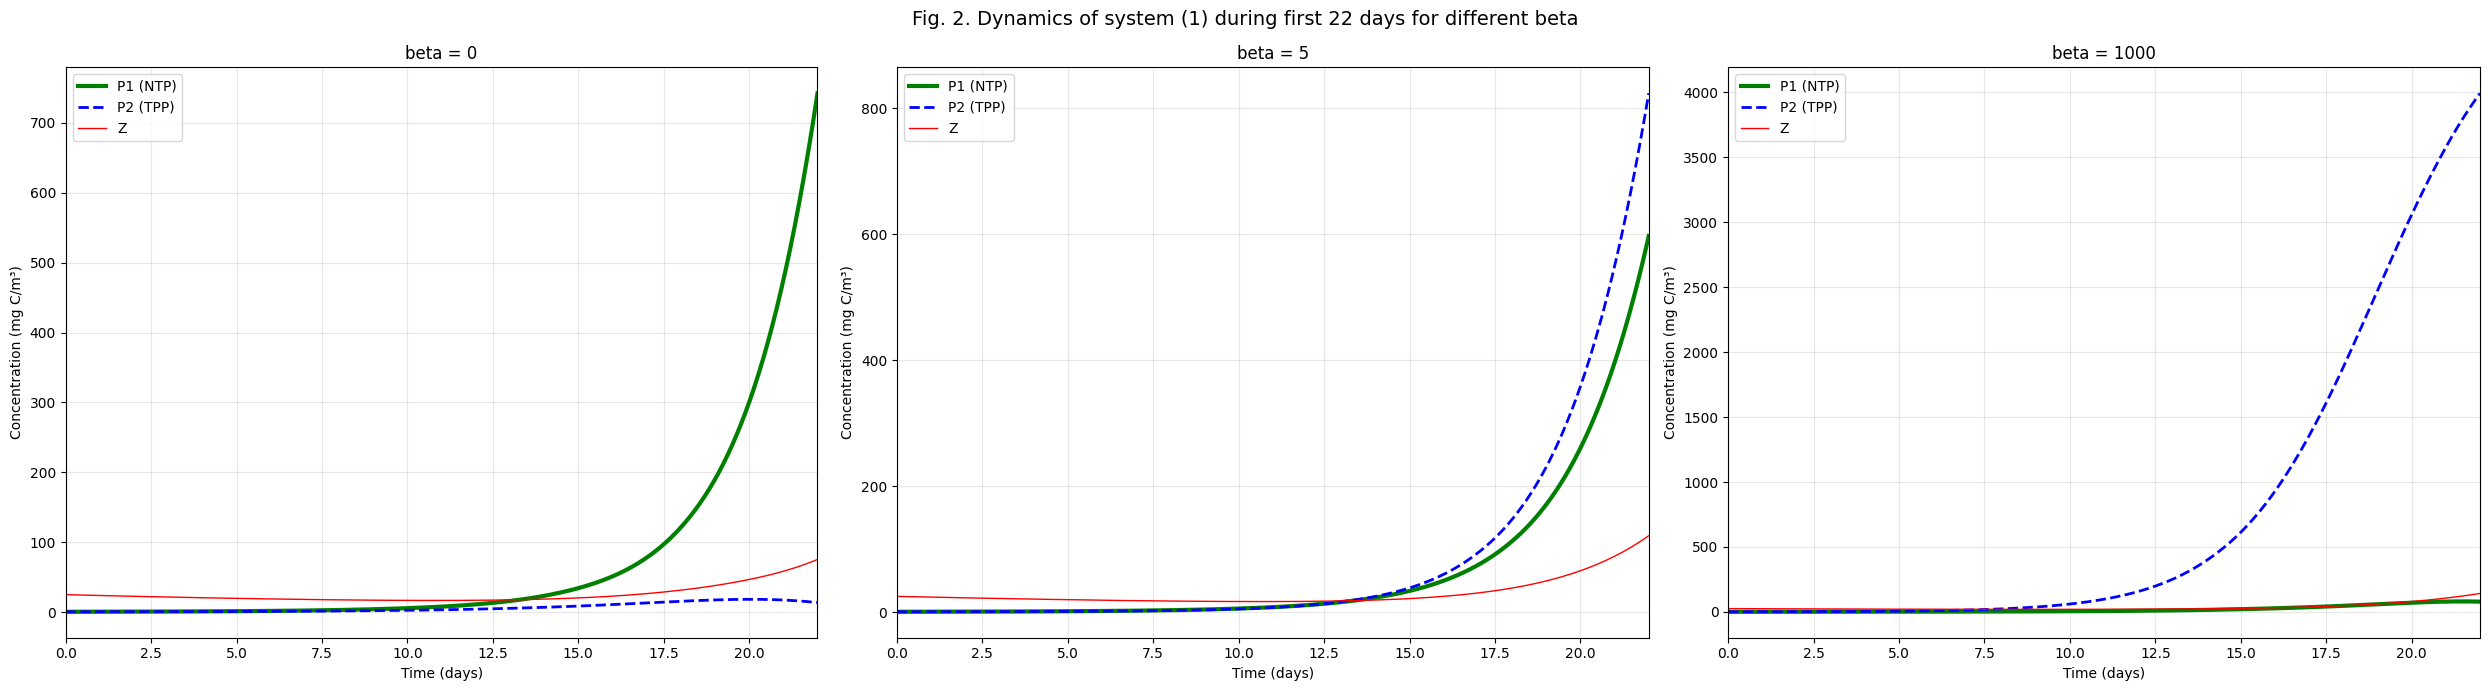

In [356]:
fig, axes = plt.subplots(1, 3, figsize=(25, 7))
fig.suptitle('Fig. 2. Dynamics of system (1) during first 22 days for different beta', fontsize=14)

names_fig2 = ['Рис.2a (beta=0)', 'Рис.2b (beta=5)', 'Рис.2c (beta=1000)']
for i, name in enumerate(names_fig2):
    ax = axes[i]
    solution = results[name]
    
    ax.plot(solution.t, solution.y[0], 'g', linewidth=3, label='P1 (NTP)')
    ax.plot(solution.t, solution.y[1], 'b', linewidth=2, label='P2 (TPP)', ls = '--')
    ax.plot(solution.t, solution.y[2], 'r', linewidth=1, label='Z')
    
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Concentration (mg C/m³)')
    ax.set_title(f'beta = {scenarios[name]["beta"]}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 22)

plt.tight_layout()
plt.show()

### t = 22, бета =  [0, 5, 1000]
Совпадают все тенденции.

В первом случае растет популяция NTP, а ТТР остается низкой. 

Во втором и NTP, и ТТР достигают высокой концентрации. 

В третьем NTP низкая, ТТР растет. 

В статье под графиками этих величин сказано следующее: Dynamics of system (1) during first 22 days for different b, with all the other parameter values and initial conditions are same as in Table 1. (a) At b = 0, NTP reach high
bloom concentration while TPP concentration remains low. (b) For b = 5, both NTP and TPP reach high bloom concentration. (c) For b = 1000, TPP reach high bloom
concentration while NTP concentration remains low.

### Фазовые портреты для рисунка 2

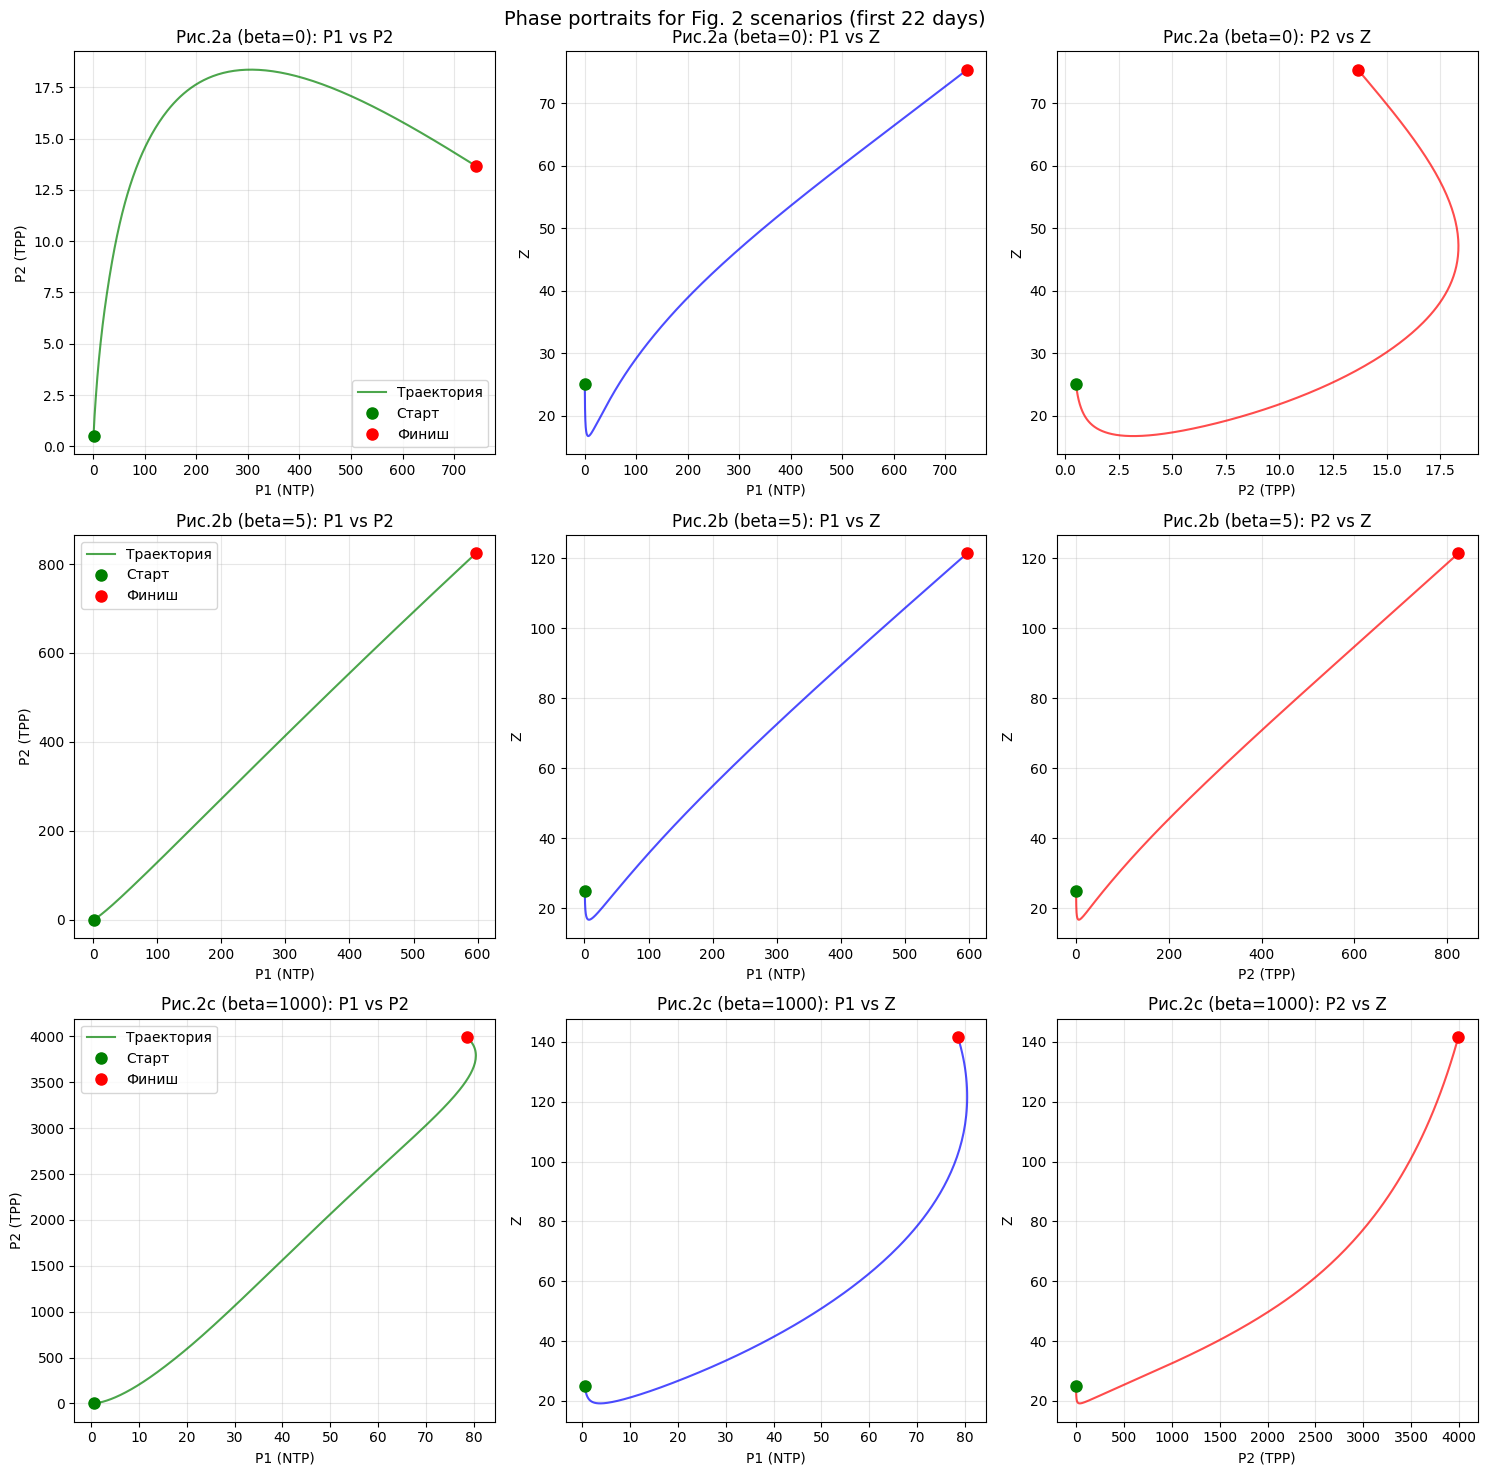

In [357]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Phase portraits for Fig. 2 scenarios (first 22 days)', fontsize=14)

names_fig2 = ['Рис.2a (beta=0)', 'Рис.2b (beta=5)', 'Рис.2c (beta=1000)']

for i, name in enumerate(names_fig2):
    solution = results[name]
    
    # P1 vs P2
    ax = axes[i, 0]
    ax.plot(solution.y[0], solution.y[1], 'g-', linewidth=1.5, alpha=0.7, label='Траектория')
    ax.plot(solution.y[0][0], solution.y[1][0], 'go', markersize=8, label='Старт')
    ax.plot(solution.y[0][-1], solution.y[1][-1], 'ro', markersize=8, label='Финиш')
    ax.set_xlabel('P1 (NTP)')
    ax.set_ylabel('P2 (TPP)')
    ax.set_title(f'{name}: P1 vs P2')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # P1 vs Z
    ax = axes[i, 1]
    ax.plot(solution.y[0], solution.y[2], 'b-', linewidth=1.5, alpha=0.7)
    ax.plot(solution.y[0][0], solution.y[2][0], 'go', markersize=8)
    ax.plot(solution.y[0][-1], solution.y[2][-1], 'ro', markersize=8)
    ax.set_xlabel('P1 (NTP)')
    ax.set_ylabel('Z')
    ax.set_title(f'{name}: P1 vs Z')
    ax.grid(True, alpha=0.3)
    
    # P2 vs Z
    ax = axes[i, 2]
    ax.plot(solution.y[1], solution.y[2], 'r-', linewidth=1.5, alpha=0.7)
    ax.plot(solution.y[1][0], solution.y[2][0], 'go', markersize=8)
    ax.plot(solution.y[1][-1], solution.y[2][-1], 'ro', markersize=8)
    ax.set_xlabel('P2 (TPP)')
    ax.set_ylabel('Z')
    ax.set_title(f'{name}: P2 vs Z')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Код для графиков (временные ряды, длинный срок)

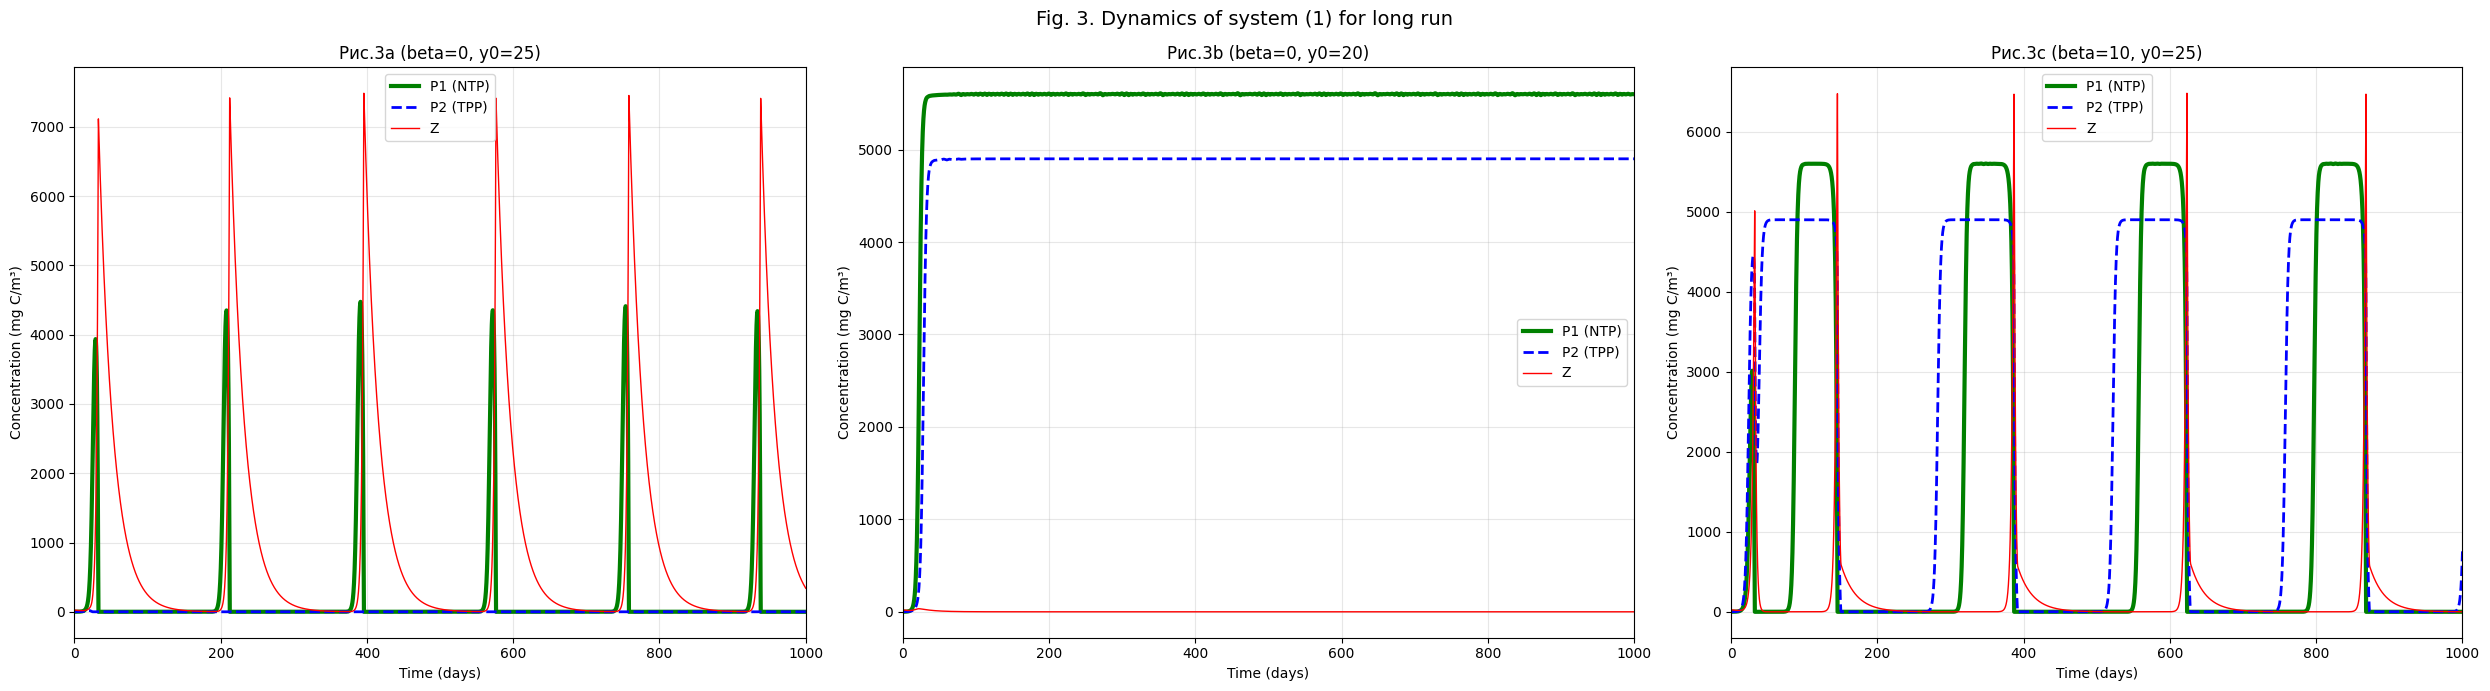

In [358]:
fig, axes = plt.subplots(1, 3, figsize=(25, 7))
fig.suptitle('Fig. 3. Dynamics of system (1) for long run', fontsize=14)

names_fig3 = ['Рис.3a (beta=0, y0=25)', 'Рис.3b (beta=0, y0=20)', 'Рис.3c (beta=10, y0=25)']
for i, name in enumerate(names_fig3):
    ax = axes[i]
    solution = results[name]
    
    ax.plot(solution.t, solution.y[0], 'g', linewidth=3, label='P1 (NTP)')
    ax.plot(solution.t, solution.y[1], 'b', linewidth=2, label='P2 (TPP)', ls = '--')
    ax.plot(solution.t, solution.y[2], 'r', linewidth=1, label='Z')
    
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Concentration (mg C/m³)')
    ax.set_title(name)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1000)

plt.tight_layout()
plt.show()


### t = 1000
##### a) For b = 0, with initial concentrations (0.5,0.5,25)
Популяции зоопланктона и NTP сосуществуют в цикле, в то время как TTP вымер ("Dynamics of system (1) for long run, with all the other parameter values are same as in Table 1. Here, bold continuous line (green) represents the concentration of NTP
population, dashed line (blue) represents the concentration of TPP population and thin continuous line (red) represents the concentration of zooplankton population. (a) At
b = 0, with initial concentrations (0.5,0.5,25) NTP and zooplankton oscillate while TPP population extinct." )
#####  b) For b = 0, with initial concentrations (0.5,0.5,20)
"(b) For b = 0, with initial concentrations (0.5,0.5,20) both NTP and TPP survive and settle down to steady state values whereas zooplankton population extinct." подтверждается
##### c) For b = 10
Подтверждается прогноз, что все три вида сосуществуют в равновесии -- (b) For b = 0, with initial concentrations (0.5,0.5,20) both NTP and
TPP survive and settle down to steady state values whereas zooplankton population extinct. (c) For b = 10, allthe populations survive and system settles down to a stable limit
cycle. (For interpretation of the references to color in this figure legend, the reader is referred to the web version of the article.)

### Фазовые портреты для рисунка 3

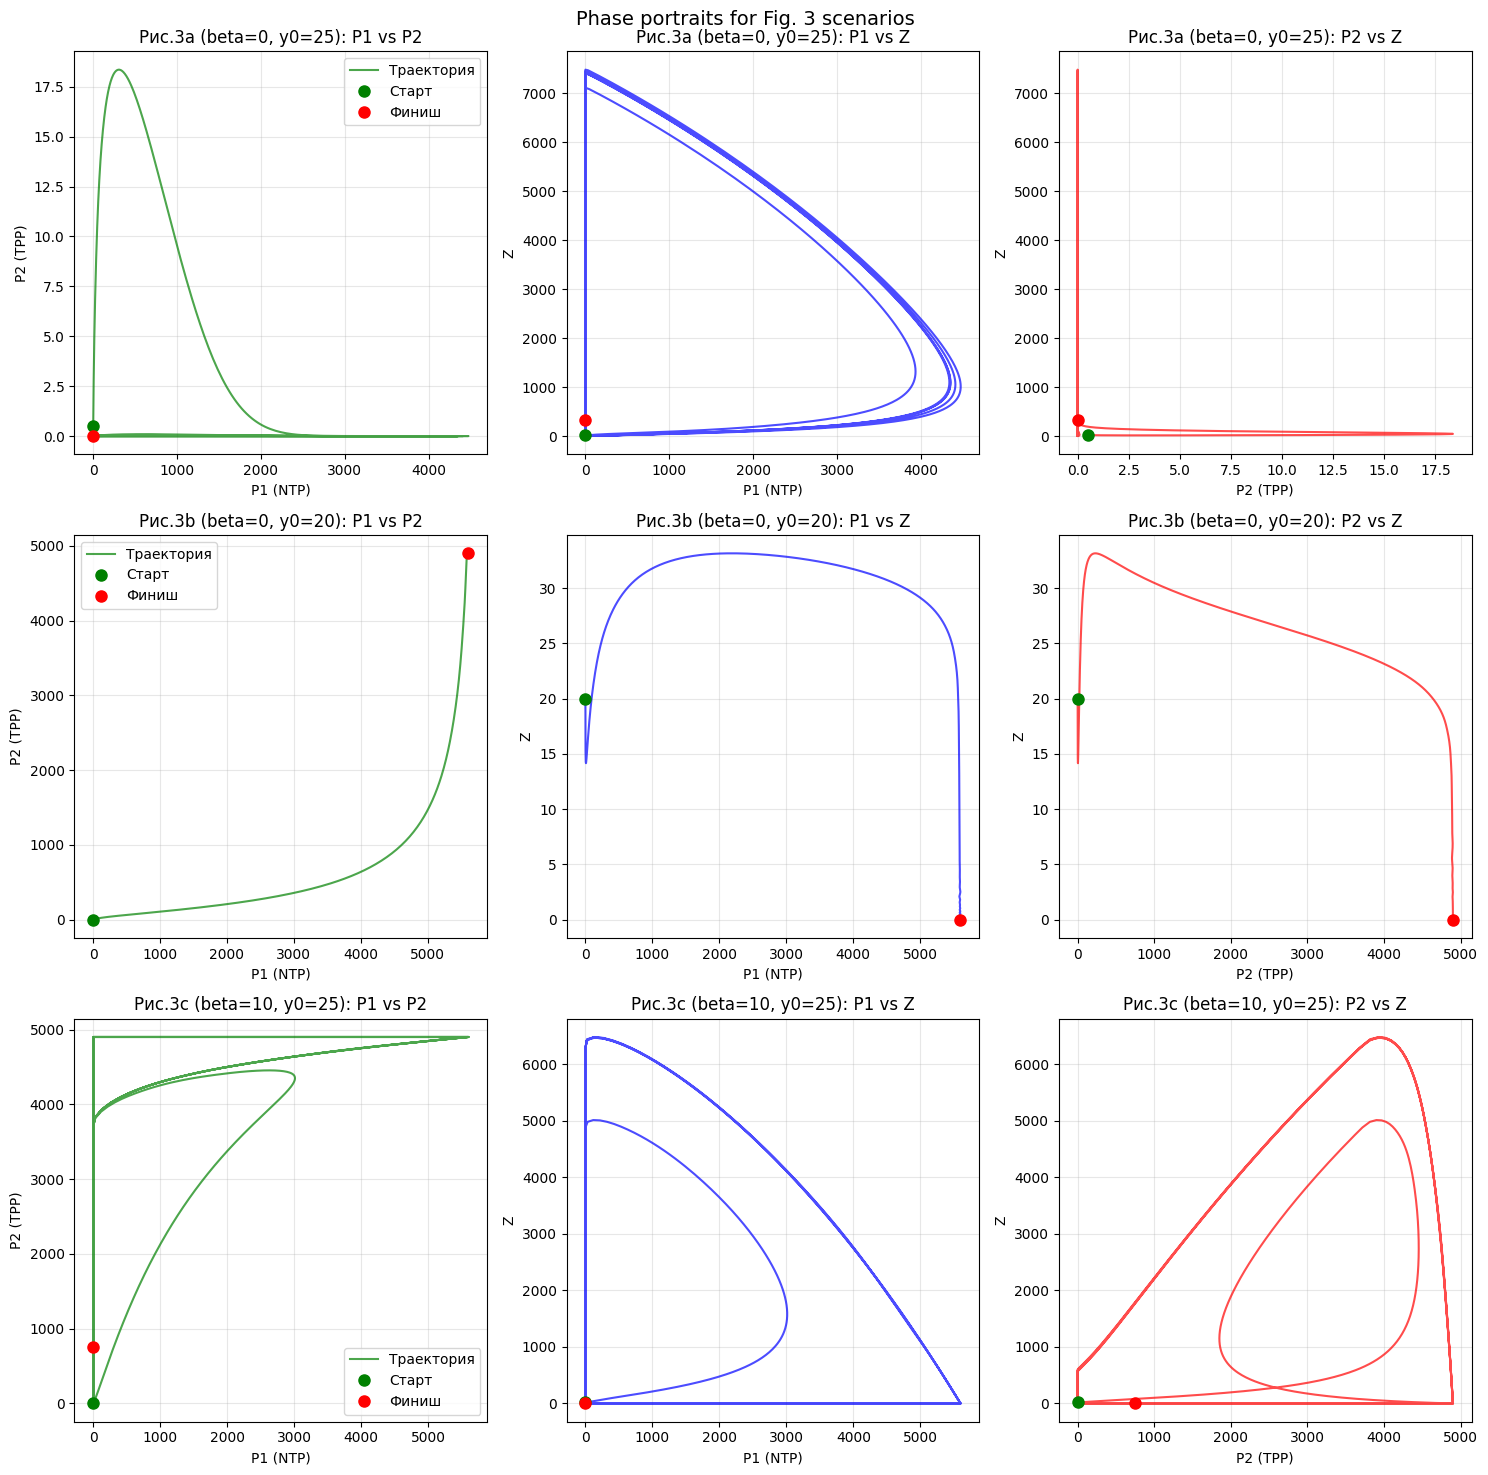

In [359]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Phase portraits for Fig. 3 scenarios', fontsize=14)

names_fig3 = ['Рис.3a (beta=0, y0=25)', 'Рис.3b (beta=0, y0=20)', 'Рис.3c (beta=10, y0=25)']

for i, name in enumerate(names_fig3):
    solution = results[name]
    
    # P1 vs P2
    ax = axes[i, 0]
    ax.plot(solution.y[0], solution.y[1], 'g-', linewidth=1.5, alpha=0.7, label='Траектория')
    ax.plot(solution.y[0][0], solution.y[1][0], 'go', markersize=8, label='Старт')
    ax.plot(solution.y[0][-1], solution.y[1][-1], 'ro', markersize=8, label='Финиш')
    ax.set_xlabel('P1 (NTP)')
    ax.set_ylabel('P2 (TPP)')
    ax.set_title(f'{name}: P1 vs P2')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # P1 vs Z
    ax = axes[i, 1]
    ax.plot(solution.y[0], solution.y[2], 'b-', linewidth=1.5, alpha=0.7)
    ax.plot(solution.y[0][0], solution.y[2][0], 'go', markersize=8)
    ax.plot(solution.y[0][-1], solution.y[2][-1], 'ro', markersize=8)
    ax.set_xlabel('P1 (NTP)')
    ax.set_ylabel('Z')
    ax.set_title(f'{name}: P1 vs Z')
    ax.grid(True, alpha=0.3)
    
    # P2 vs Z
    ax = axes[i, 2]
    ax.plot(solution.y[1], solution.y[2], 'r-', linewidth=1.5, alpha=0.7)
    ax.plot(solution.y[1][0], solution.y[2][0], 'go', markersize=8)
    ax.plot(solution.y[1][-1], solution.y[2][-1], 'ro', markersize=8)
    ax.set_xlabel('P2 (TPP)')
    ax.set_ylabel('Z')
    ax.set_title(f'{name}: P2 vs Z')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ЧАСТЬ 2. АКАР

## Тривиальный случай. Управление Р2 (для демонстрации работы функции управления я возьму случай доминирования токсичного планктона (рисунок с)). Целевой показатель $P_2^* = 50$
    {
        'beta': 1000,
        'y0': (0.5, 0.5, 25),
        't_max': 22,
        't_points': 500
    }
    

### Вывод закона управления (Случай 1) (более подробно в тетради)

1. целевой показатель: $P_2^* = 50$ мг C/м³

2. макропеременная: $\psi = P_2 - P_2^*$

3. желаемая динамика: $\dot{\psi} = -\psi/T$

4. производная через модель: $\dot{\psi} = \dot{P}_2 = f(P_1, P_2, Z) + u$

5. желаемая динамика должна совпадать с реальной : $f(P_1, P_2, Z) + u = -\psi/T$

6. нахождение закона управления $u$: $u = -\psi/T - f(P_1, P_2, Z)$

7. финальная формула для закона управления после подстановки $f$: 
   $$u = -\frac{P_2 - P_2^*}{T} - r_2 P_2 \left(1 - \frac{P_2 + \alpha_2 P_1}{K_2}\right) + \frac{w_2 P_2 Z}{d_2 + P_2 + \beta P_1}$$

In [360]:
# y0 = (0.5, 0.5, 25) 
# beta = 1000
# t = 200                     # посмотрю на динамику, не хочу ограничиваться 22 днями, вдруг силы воздейсвия u за время T не хватит
# #t = 1000

# # дублирую параметры для системы из таблицы 1 
# r1, r2    = 0.56, 0.49
# alpha1    =  alpha2  =  0       # параметры неизменяемы, позволю себе это
# k1, k2    = 5600, 4900
# w1        =    w2    =  0.5
# d1        =    d2    =  30
# c         = 0.05 


# # целевой параметр
# p2_target = 2500

# для  сценария доминирования K1 < alfa1*K2
y0 = (0.5, 0.5, 25)  
beta = 5                    # кажется, что больше всех соответствует реальному эксперементу -- зоопланктон предпочитает ntp, но при необходимости ест ttp
t = 400                     # посмотрю на динамику, не хочу ограничиваться 22 днями, вдруг силы воздейсвия u за время T не хватит
#t = 1000

# дублирую параметры для системы из таблицы 1 
r1, r2    = 0.56, 0.49
alpha1    = 1
alpha2  =  0       # параметры неизменяемы, позволю себе это
k1, k2    = 1000, 1000          # создам небольшие условия для доминирования ttp
w1        =    w2    =  0.3
d1        =    d2    =  30
c         = 0.05 


# целевой параметр
p2_target = 400

In [361]:
#для читаемости и чистоты кода добавлю отдельное вычисление u

def compute_u(p1, p2, z, params, T, p2_target):
    """Вычисляет управление u в каждый момент времени"""
    r1, r2, k1, k2, alpha1, alpha2, w1, w2, d1, d2, beta, c = params
    
    psi = p2 - p2_target
    u = -psi / T - r2 * p2 * (1 - (p2 + alpha2 * p1) / k2) + (w2 * p2 * z) / (d2 + p2 + beta * p1)
    return u

In [362]:
# функция замкнутой системы

def closed_model(t, y, params, T, p2_target):
    """  замкнутая система с управлением (тривиальный cлучай)
    d     --    полунасыщение, 
    beta  --    избегание,
    r     --    врожденная скорость роста (сколько потомства дает клетка в ед вр)
    k     --    емкость среды (max P)
    alfa  --    конкурентное воздействие (насколько 1 вид забирает возможность размножаться у второго)
    w     --    скорость поедания (сколько Р съедает 1z за ед вр)
    c     --    коэффициент вымирания z
    p2_target --целевое значение популяции токсичного планктона
    y =         [p1, p2, z] для сигнатуры solutionve_ipv
     
    """
    p1, p2, z = y
    r1, r2, k1, k2, alpha1, alpha2, w1, w2, d1, d2, beta, c = params
    
    u = compute_u(p1,p2,z,params,T, p2_target)

    # система уравнений (для популяции 2 долбавлю функцию управления u)
    dP1dt = r1*p1*(1 - (alpha1*p2 + p1)/k1) - (w1*p1*z)/(d1+p1)
    dP2dt = r2*p2*(1 - (alpha2*p1 + p2)/k2) - (w2*p2*z)/(d2+p2+ beta*p1) + u
    dZdt = (w1*p1*z)/(d1+p1) - (w2*p2*z)/(d2+p2+beta*p1) - c*z

    return [dP1dt, dP2dt, dZdt]

In [363]:
# параметры для solve_ivp
params = (r1, r2, k1, k2, alpha1, alpha2, w1, w2, d1, d2, beta, c)
#T_values = [0.5, 1.0, 2.0]
T_values = [1, 5, 10]
results = {}

In [364]:
t = 400
for T in T_values:
    solution = solve_ivp(
        fun=closed_model,
        t_span=(0, t),
        y0=y0,
        method='RK45',
        t_eval=np.linspace(0, t, 1000),
        args=(params, T, p2_target),
        events=event_negative,
    )
    results[T] = solution
    
    if solution.status == 1 and solution.t_events[0].size > 0:
        print(f"ВНИМАНИЕ: Интегрирование остановлено при t={solution.t_events[0][0]:.3f} из-за отрицательной биомассы!")
    print(f"Успешно: {solution.success}")
    print(f"Причина остановки: {solution.message}")
    print(f"Количество шагов: {len(solution.t)}")
    print(f"  Финал: P1={solution.y[0][-1]:.2f}, P2={solution.y[1][-1]:.2f}, Z={solution.y[2][-1]:.2f}\n")

Успешно: True
Причина остановки: The solver successfully reached the end of the integration interval.
Количество шагов: 1000
  Финал: P1=128.93, P2=400.00, Z=0.00

Успешно: True
Причина остановки: The solver successfully reached the end of the integration interval.
Количество шагов: 1000
  Финал: P1=529.34, P2=400.00, Z=0.00

Успешно: True
Причина остановки: The solver successfully reached the end of the integration interval.
Количество шагов: 1000
  Финал: P1=511.50, P2=400.00, Z=0.00



## Вывод по результатам исследования влияния параметра $T$ 

### 1. Случай $T = 1$ 

При $T = 1$ управление является достаточно быстрым и эффективно удерживает $P_2$ на целевом уровне. $P_1$ и $Z$ сохраняют естественную колебательную динамику, не затухая полностью. Это экологически реалистичное поведение: зоопланктон периодически выедает фитопланктон, тот восстанавливается, и цикл повторяется

### 2. Случай $T = 5$ 

При $T = 5$ управление действует медленнее, что позволяет $P_1$ и $Z$ проявлять более выраженную циклическую динамику. На колебания остальных популяций эффекта не оказывает

### 3. Случай $T = 10$ 

При $T = 10$ управление является наиболее медленным. $P_2$ по-прежнему удерживается на целевом уровне, а $P_1$ и $Z$ сохраняют колебательное поведение. Более медленное управление позволяет системе сохранять естественную динамику, что экологически предпочтительно.

## Общий вывод

Проведённое исследование показало, что метод АКАР успешно решает задачу удержания биомассы токсичного фитопланктона на целевом уровне $P_2^* = 400$ мг C/м³ во всех трёх рассмотренных случаях. При выбранных параметрах системы ($\beta = 5$, $K_1 = 1000$, $K_2 = 1000$) все значения $T$ обеспечивают устойчивую работу системы с сохранением естественной циклической динамики популяций.


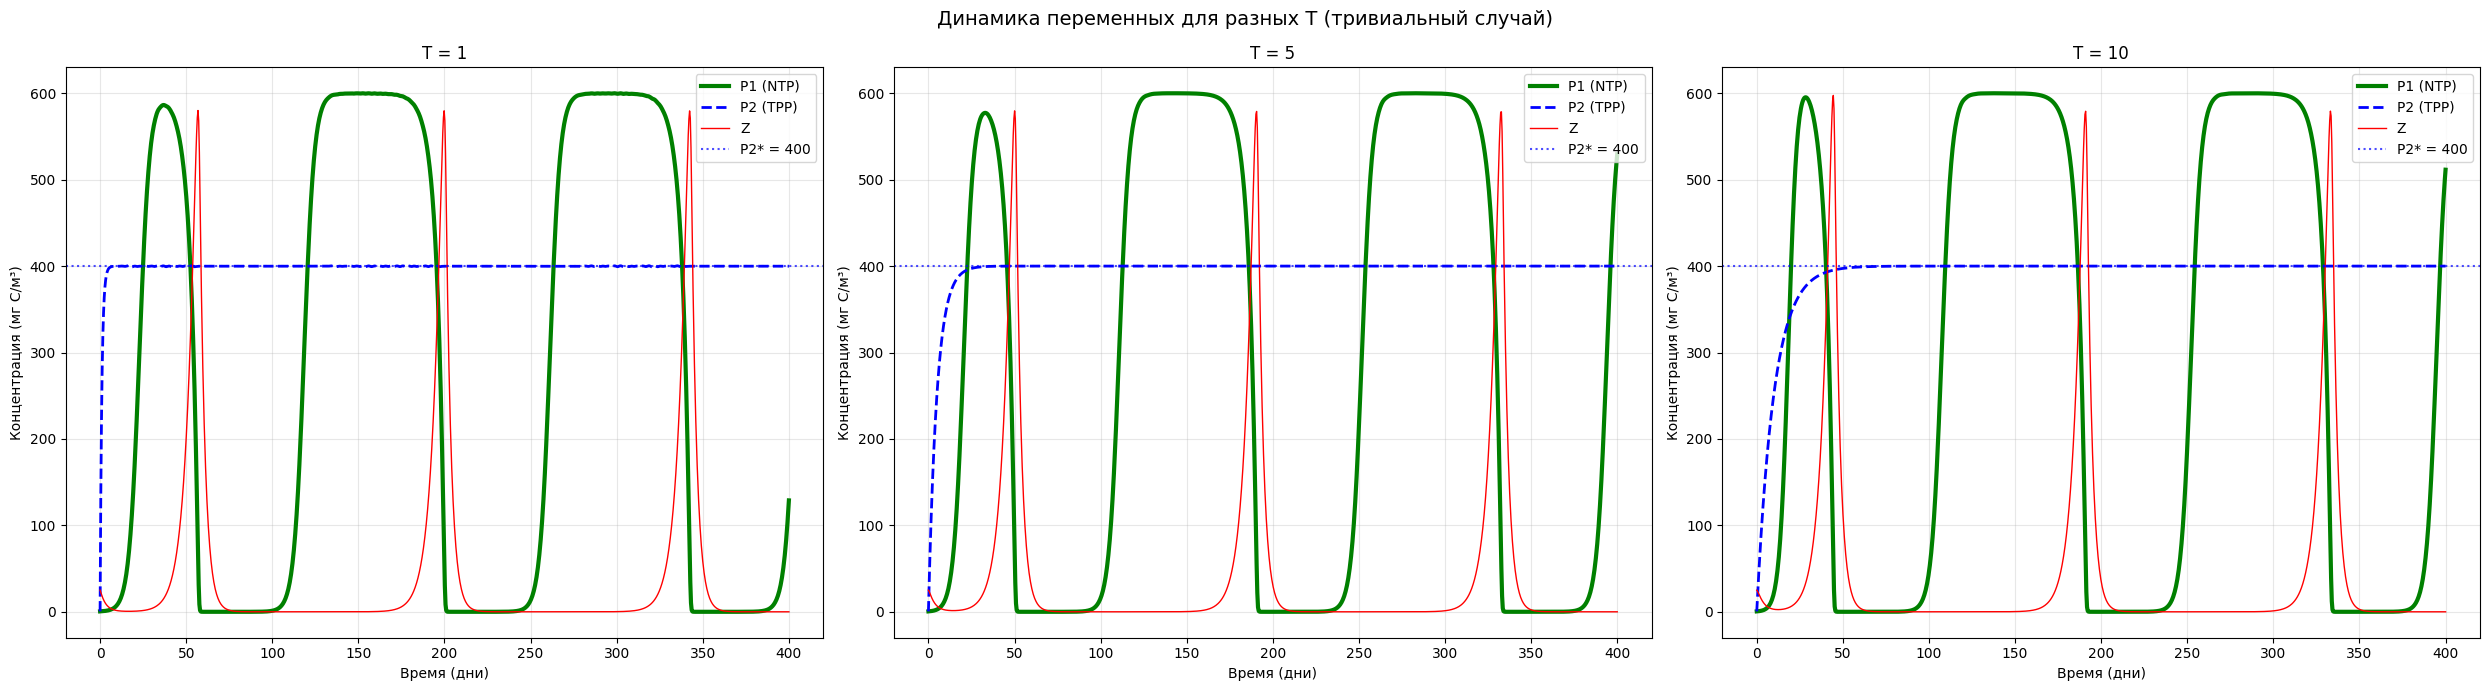

In [365]:
# временной ряд
fig, axes = plt.subplots(1, 3, figsize=(25, 7))
fig.suptitle('Динамика переменных для разных T (тривиальный случай)', fontsize=14)

for i, T in enumerate(T_values):
    ax = axes[i]
    solution = results[T]  
    
    ax.plot(solution.t, solution.y[0], 'g', linewidth=3, label='P1 (NTP)')
    ax.plot(solution.t, solution.y[1], 'b', linewidth=2, label='P2 (TPP)', ls='--')
    ax.plot(solution.t, solution.y[2], 'r', linewidth=1, label='Z')
    
    # целевой уровень
    ax.axhline(y=p2_target, color='b', linestyle=':', linewidth=1.5, alpha=0.7, label=f'P2* = {p2_target}')
    
    ax.set_xlabel('Время (дни)')
    ax.set_ylabel('Концентрация (мг C/м³)')
    ax.set_title(f'T = {T}')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

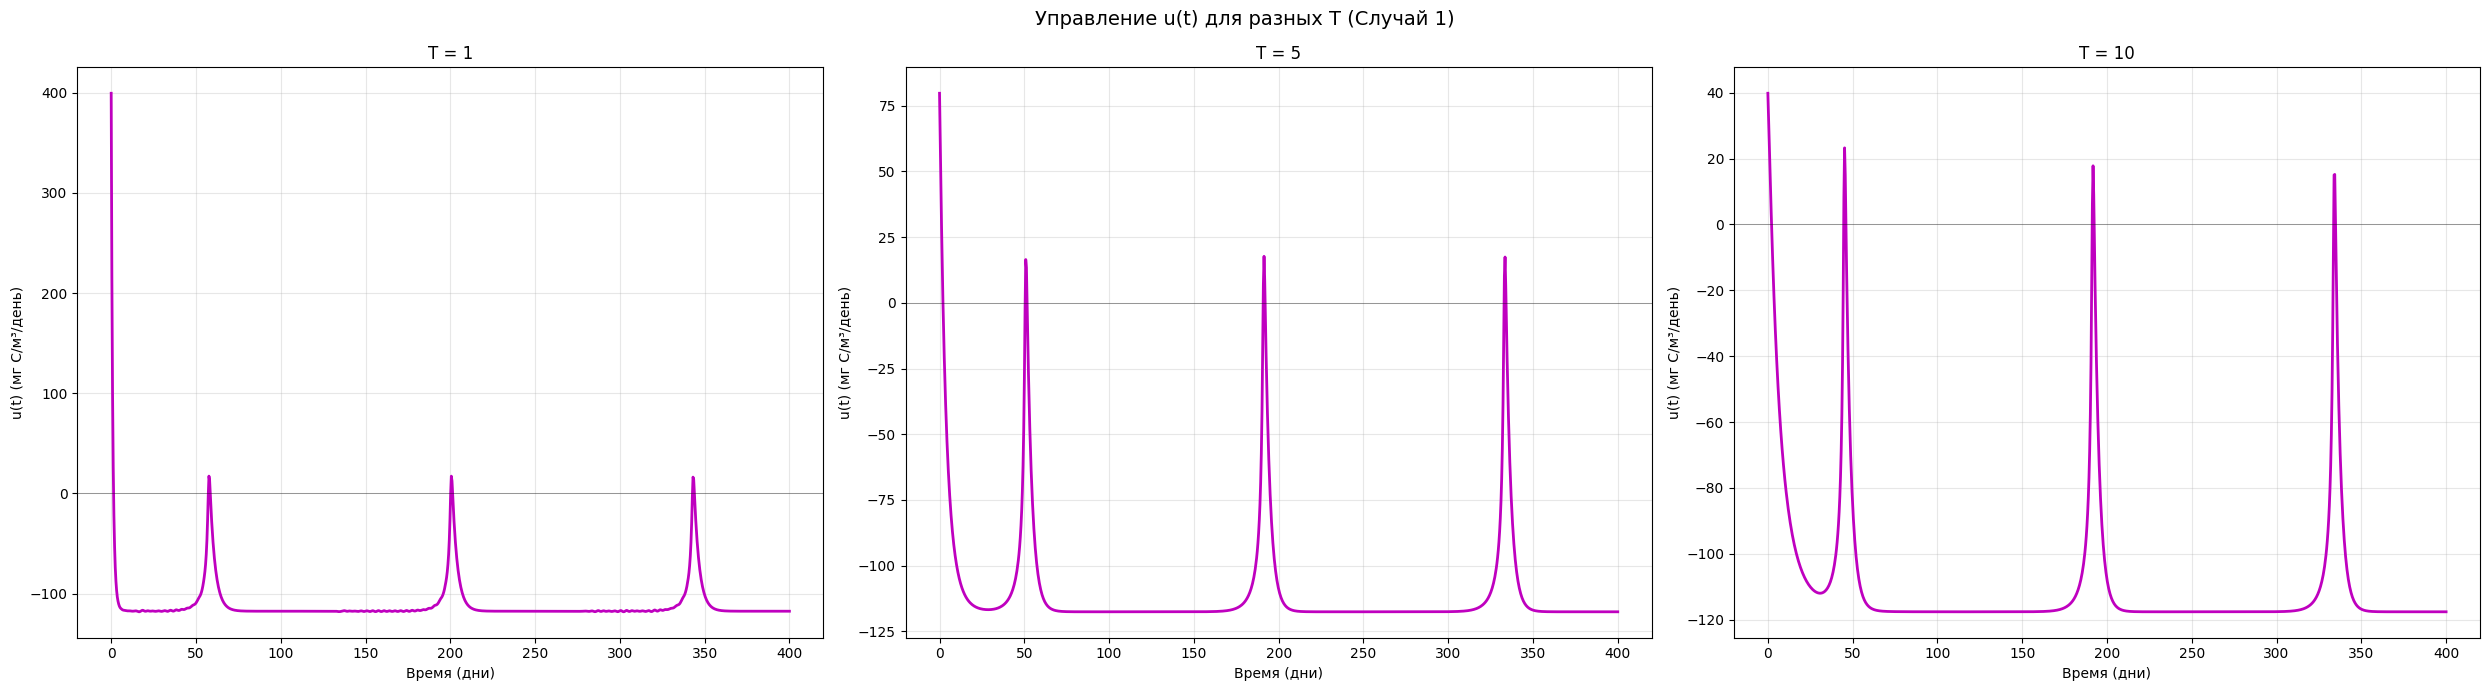

In [366]:
# график для функции управления 
fig, axes = plt.subplots(1, 3, figsize=(25, 7))
fig.suptitle('Управление u(t) для разных T (Случай 1)', fontsize=14)

for i, T in enumerate(T_values):
    ax = axes[i]
    solution = results[T]
    t = solution.t
    
    u_values = np.array([compute_u(solution.y[0][j], solution.y[1][j], solution.y[2][j], params, T, p2_target) 
                         for j in range(len(t))])
    
    ax.plot(t, u_values, 'm-', linewidth=2)
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
    
    ax.set_xlabel('Время (дни)')
    ax.set_ylabel('u(t) (мг C/м³/день)')
    ax.set_title(f'T = {T}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

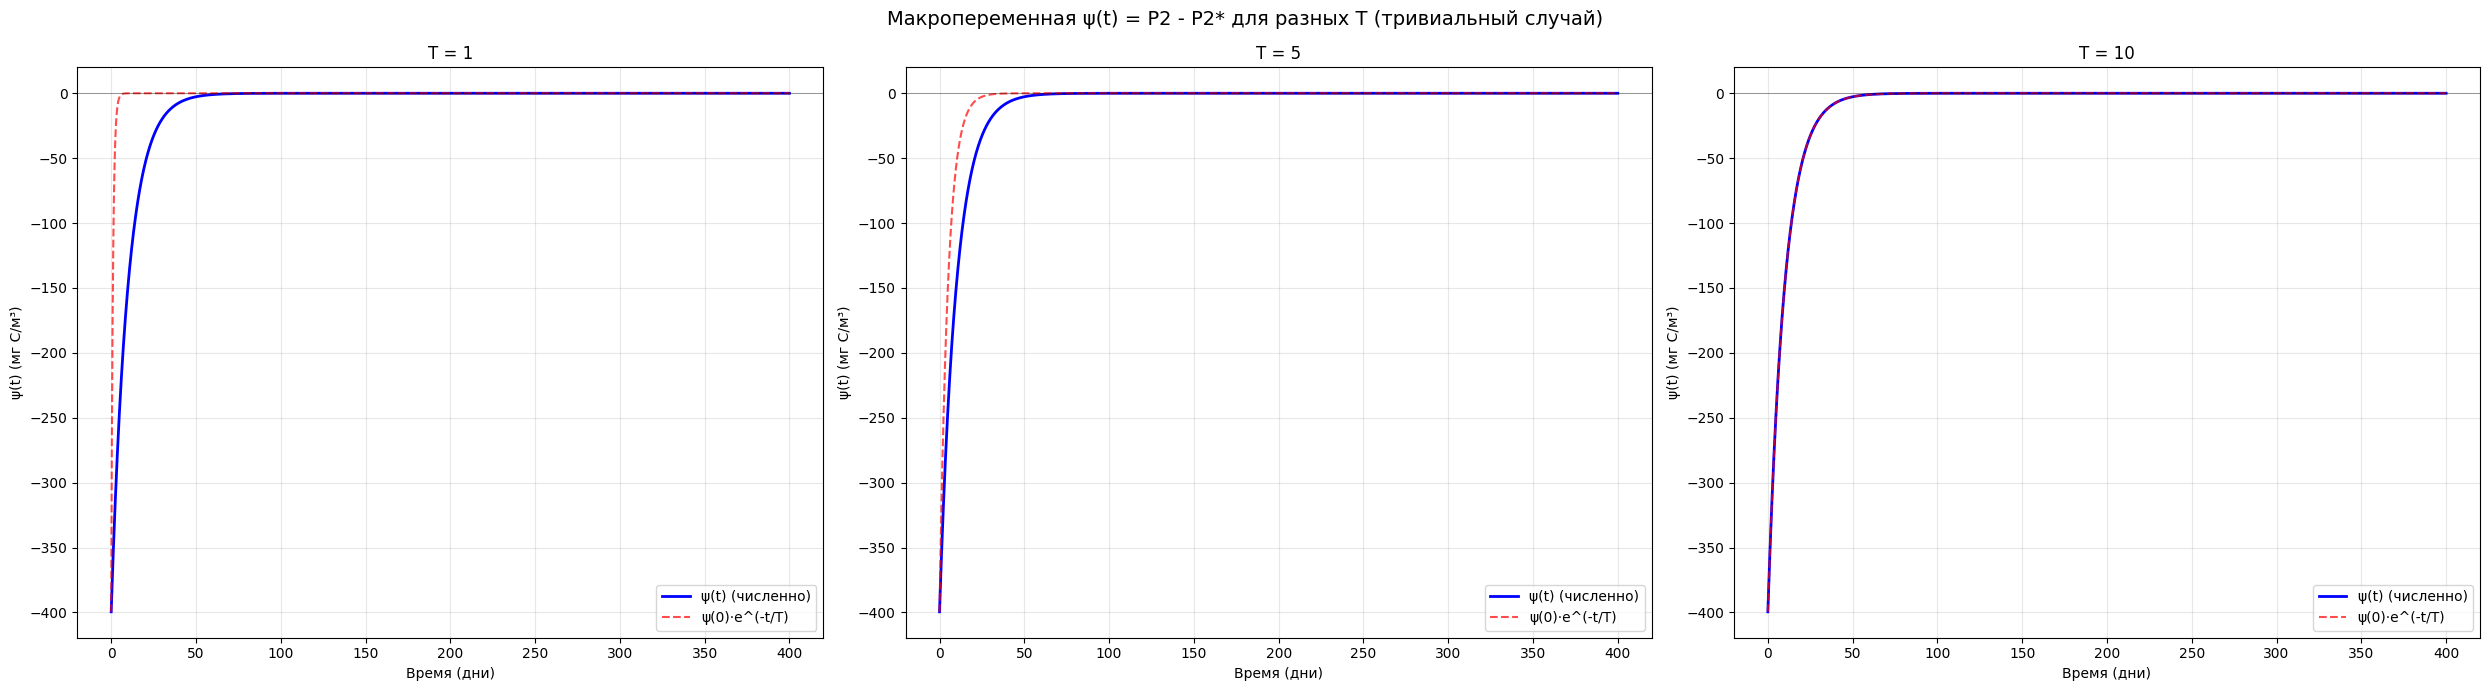

In [367]:
#  макропеременная пси
fig, axes = plt.subplots(1, 3, figsize=(25, 7))
fig.suptitle('Макропеременная ψ(t) = P2 - P2* для разных T (тривиальный случай)', fontsize=14)

for i, T in enumerate(T_values):
    ax = axes[i]
    sol = results[T]
    t = solution.t
    
    #численная экспонента
    psi = solution.y[1] - p2_target
    psi_0 = psi[0]
    
    # теоретическая экспонента
    psi_theory = psi_0 * np.exp(-t / T)
    
    ax.plot(t, psi, 'b-', linewidth=2, label='ψ(t) (численно)')
    ax.plot(t, psi_theory, 'r--', linewidth=1.5, alpha=0.7, label='ψ(0)·e^(-t/T)')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
    
    ax.set_xlabel('Время (дни)')
    ax.set_ylabel('ψ(t) (мг C/м³)')
    ax.set_title(f'T = {T}')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


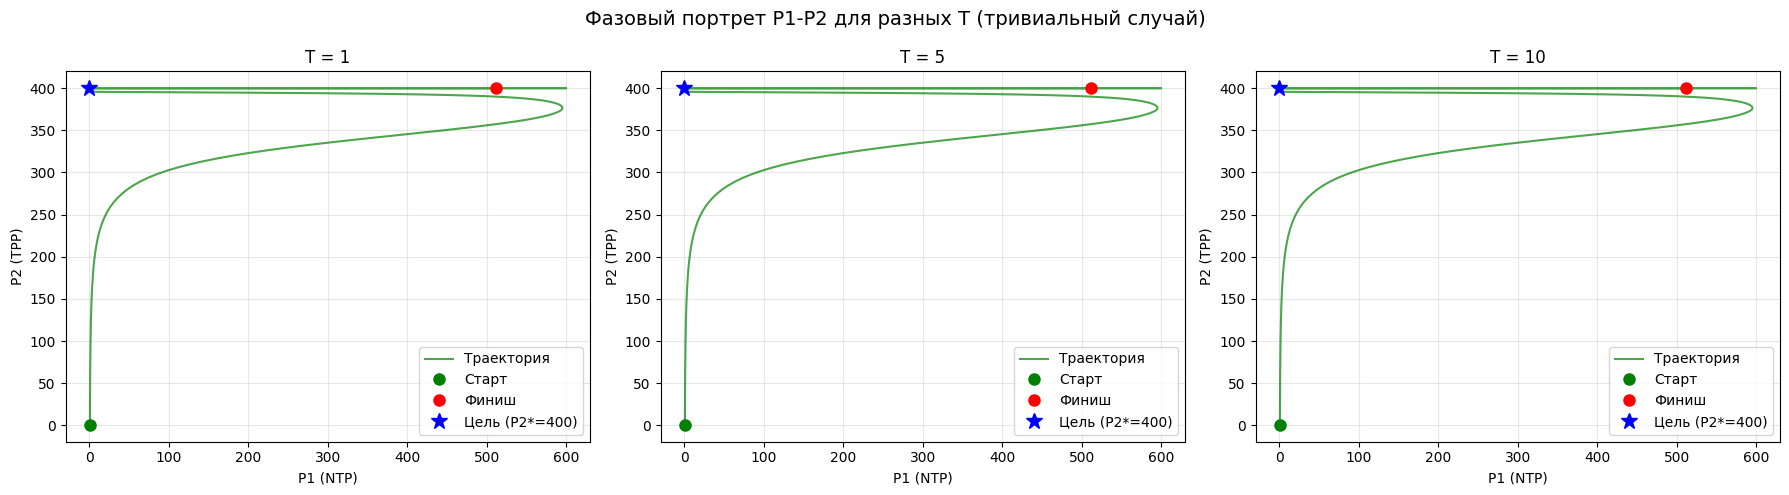

In [368]:
# фазовый портрет P1-P2 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Фазовый портрет P1-P2 для разных T (тривиальный случай)', fontsize=14)

for i, T in enumerate(T_values):
    ax = axes[i]
    sol = results[T]
    
    # траектория
    ax.plot(solution.y[0], solution.y[1], 'g-', linewidth=1.5, alpha=0.7, label='Траектория')
    ax.plot(solution.y[0][0], solution.y[1][0], 'go', markersize=8, label='Старт')
    ax.plot(solution.y[0][-1], solution.y[1][-1], 'ro', markersize=8, label='Финиш')
    
    # целевое состояние
    ax.plot(0, p2_target, 'b*', markersize=12, label=f'Цель (P2*={p2_target})')
    
    ax.set_xlabel('P1 (NTP)')
    ax.set_ylabel('P2 (TPP)')
    ax.set_title(f'T = {T}')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## Вывод закона управления для Случая 2 (двухшаговый АКАР)

Заменяем управление в уравнении для $P_1$:

$$
\dot{P}_1 = r_1 P_1 \left(1 - \frac{P_1 + \alpha_1 P_2}{K_1}\right) - \frac{w_1 P_1 Z}{d_1 + P_1} + u
$$

Поскольку управление $u$ входит только в уравнение для $P_1$, а макропеременная задана через $P_2$, прямое приравнивание $\dot{\psi} = -\psi/T_2$ не даст выражения для $u$. Вместо этого вводим вспомогательную макропеременную $\psi_2 = P_1 - \phi$, где $\phi$ — функция для $P_1$, которую подбираем так, чтобы при $P_1 = \phi$ система обеспечивала нужную динамику для $P_2$.

Таким образом, мы требуем:

1. $\psi_2 \to 0$ (т.е. $P_1 \to \phi$) с заданной скоростью $T_1$.
2. При $P_1 = \phi$ основная макропеременная $\psi = P_2 - P_2^*$ стремится к нулю с заданной скоростью $T_2$.



### Шаг 1. Вывод управления $u$

Зададим желаемую динамику для $\psi_2$:

$$
\dot{\psi}_2 = -\frac{\psi_2}{T_1}
$$

$$
\dot{\psi}_2 = \dot{P}_1 - \dot{\phi} = r_1 P_1 \left(1 - \frac{P_1 + \alpha_1 P_2}{K_1}\right) - \frac{w_1 P_1 Z}{d_1 + P_1} + u - \dot{\phi}
$$

Приравниваем:

$$
r_1 P_1 \left(1 - \frac{P_1 + \alpha_1 P_2}{K_1}\right) - \frac{w_1 P_1 Z}{d_1 + P_1} + u - \dot{\phi} = -\frac{P_1 - \phi}{T_1}
$$

Выражаем $u$:

$$
u = -\frac{P_1 - \phi}{T_1} - r_1 P_1 \left(1 - \frac{P_1 + \alpha_1 P_2}{K_1}\right) + \frac{w_1 P_1 Z}{d_1 + P_1} + \dot{\phi}
$$



### Шаг 2. Вывод $\phi$

Потребуем, чтобы при подстановке $P_1 = \phi$ система обеспечивала желаемую динамику для $P_2$:

$$
\dot{\psi} = -\frac{\psi}{T_2}, \quad \psi = P_2 - P_2^*
$$

Так как $\dot{\psi} = \dot{P}_2$:

$$
\dot{P}_{2,\; P_1 = \phi} = -\frac{P_2 - P_2^*}{T_2}
$$

Подставляем в выражение для $\dot{P}_2$ с заменой $P_1$ на $\phi$:

$$
r_2 P_2 \left(1 - \frac{P_2 + \alpha_2 \phi}{K_2}\right) - \frac{w_2 P_2 Z}{d_2 + P_2 + \beta \phi} = -\frac{P_2 - P_2^*}{T_2}
$$

Решаем относительно $\phi$:

$$
\phi = \frac{1}{\beta} \left( 
\frac{w_2 P_2 Z}{r_2 P_2 \left(1 - \frac{P_2 + \alpha_2 \phi}{K_2}\right) + \frac{P_2 - P_2^*}{T_2}} 
- d_2 - P_2
\right)
$$

**Проблема:** $\phi$ входит в правую часть неявно (через $\alpha_2 \phi$ в знаменателе), поэтому уравнение решается **численно** относительно $\phi$ на каждом шаге интегрирования.

Я буду учитытьвать параметры из статьи для аналитического рещения для $\phi$, приму, что $\alpha_2 = 0$

$$
\phi = \frac{1}{\beta} \left( 
\frac{w_2 P_2 Z}{r_2 P_2 \left(1 - \frac{P_2}{K_2}\right) + \frac{P_2 - P_2^*}{T_2}} 
- d_2 - P_2
\right)
$$

### Шаг 3. Производная $\dot{\phi}$

Так как $\phi$ зависит от $P_1, P_2, Z$, полная производная по времени:

$$
\dot{\phi} =  \frac{\partial \phi}{\partial P_2} \dot{P}_2 + \frac{\partial \phi}{\partial Z} \dot{Z}
$$

Частные производные могут быть найдены аналитически (из выражения для $\phi$) или численно на каждом шаге интегрирования.



### Итоговый закон управления

$$
u = -\frac{P_1 - \phi}{T_1} - r_1 P_1 \left(1 - \frac{P_1 + \alpha_1 P_2}{K_1}\right) + \frac{w_1 P_1 Z}{d_1 + P_1} + \dot{\phi}
$$

где $\phi$ определяется из уравнения:

$$
r_2 P_2 \left(1 - \frac{P_2 + \alpha_2 \phi}{K_2}\right) - \frac{w_2 P_2 Z}{d_2 + P_2 + \beta \phi} = -\frac{P_2 - P_2^*}{T_2}
$$





а $\dot{\phi}$ вычисляется как полная производная по времени.


## Размышление, как должна отрабатывать программа
Цикл управляется внешним контуром:

1. **Перед началом выполнения** $P_2$ далеко от $P_2^*$. Ошибка $\psi = P_2 - P_2^*$ большая.

2. **Нужно вычислить $\varphi$:**
   по формуле , каким должен быть  $P_1$, чтобы $P_2$ начал снижаться.  
   для этого решить уравнение:

   $f_2(\varphi, P_2, Z) = -(P_2 - P_2^*) / T_2$  

   где $f_2$ — правая часть уравнения для $P_2$.

3. **Перехо во внутренний контур**

   Управление $u(t)$ заставляет $P_1$ стремиться к $\varphi$: 
   $u = -(P_1 - \varphi) / T_1 - f_1 + \dot{\varphi}$


4. **Когда $P_1$ достигает $\varphi$:**  
   $P_2$ начинает снижаться, потому что система теперь работает в нужном режиме.

5. **По мере снижения $P_2$:**  
   $\varphi$ пересчитывается , потому что система уже не в той точке, где была
   Это учитывается через производную $\dot{\varphi}$.

6. **внутренний контур догоняет новое $\varphi$:**  
   $P_1$ подстраивается под новое целевое значение.

7. **цикл повторяется,**  
   пока $P_2$ не достигнет $P_2^*$, то есть пока $\psi \to 0$.

### Работа с уравнением фи (   $f_2(\varphi, P_2, Z) = -(P_2 - P_2^*) / T_2$ )

$$
r_2 P_2 \left(1 - \frac{P_2 + \alpha_2 \phi}{K_2}\right) - \frac{w_2 P_2 Z}{d_2 + P_2 + \beta \phi} = -\frac{P_2 - P_2^*}{T_2}
$$

### Уравнения для естественных динамик популяций без упралвения

In [369]:
# ЕСТЕСТВЕННАЯ ДИНАМИКА P1
def f1(p1, p2, z):
    return r1 * p1 * (1 - (p1 + alpha1 * p2) / k1) - (w1 * p1 * z) / (d1 + p1)

# ЕСТЕСТВЕННАЯ ДИНАМИКА P2
def f2(p1, p2, z):
    return r2 * p2 * (1 - (p2 + alpha2 * p1) / k2) - (w2 * p2 * z) / (d2 + p2 + beta * p1)

# ЕСТЕСТВЕННАЯ ДИНАМИКА z
def fz(p1, p2, z):
    return (w1 * p1 * z) / (d1 + p1) - (w2 * p2 * z) / (d2 + p2 + beta * p1) - c * z



### Численное нахождение $\varphi$

In [370]:
def find_phi(p2, z, T2):

    A = (
        r2 * p2 * (1 - p2 / k2)
        + (p2 - p2_target) / T2
    )

    # защита от деления на ноль
    if abs(A) < 1e-12:
        return 0.01

    phi = (w2 * p2 * z / A - d2 - p2) / beta

    # биомасса не может быть отрицательной
    #phi = max(0.0, phi)
    
    return phi

### Вычисление производной $\dot{\varphi}$ через частные производные

In [371]:
def compute_dphi(p2, z, T2):
    phi = find_phi(p2, z, T2)
    
    # dphi/dp2
    # dphi_dp2 = derivative(lambda x: find_phi(x, z, T2), p2, dx=1e-6)
    
    # # dphi/dz
    # dphi_dz = derivative(lambda x: find_phi(p2, x, T2), z, dx=1e-6)

    # маленький шаг
    eps = 1e-6
    
    # Значение phi в точке (p2, z)
    phi = find_phi(p2, z, T2)
    
    # dphi/dp2
    phi_p2_plus = find_phi(p2 + eps, z, T2)
    phi_p2_minus = find_phi(p2 - eps, z, T2)
    dphi_dp2 = (phi_p2_plus - phi_p2_minus) / (2 * eps)
    
    # dphi/dz
    phi_z_plus = find_phi(p2, z + eps, T2)
    phi_z_minus = find_phi(p2, z - eps, T2)
    dphi_dz = (phi_z_plus - phi_z_minus) / (2 * eps)
    
    return phi, dphi_dp2, dphi_dz

### Вычисление функции управления u
$$
u = -\frac{P_1 - \phi}{T_1} - r_1 P_1 \left(1 - \frac{P_1 + \alpha_1 P_2}{K_1}\right) + \frac{w_1 P_1 Z}{d_1 + P_1} + \dot{\phi}
$$


In [372]:
def compute_u(p1, p2, z, T1, T2):
    # phi и её производные
    phi, dphi_dp2, dphi_dz = compute_dphi(p2, z, T2)
    
    # естественная динамика
    f1_val = f1(p1, p2, z)
    f2_val = f2(p1, p2, z)
    dzdt   = fz(p1,p2,z)
    

    # dphi/dt = dphi_dp2 * dp2dt + dphi_dz * dzdt
    dphi_dt = dphi_dp2 * f2_val + dphi_dz * dzdt
    
    # управление
    psi2 = p1 - phi
    u = -psi2 / T1 - f1_val + dphi_dt
    
    return u, phi, psi2

### Модель системы уравнений для сложного случая упраавления АКАР

In [373]:
def closed_model_2(t, y, T1, T2):
    """Замкнутая система с двухшаговым управлением"""
    p1, p2, z = y
    
    u, phi, psi2 = compute_u(p1, p2, z, T1, T2)
    
    dP1dt = r1 * p1 * (1 - (p1 + alpha1 * p2) / k1) - (w1 * p1 * z) / (d1 + p1) + u
    dP2dt = r2 * p2 * (1 - (p2 + alpha2 * p1) / k2) - (w2 * p2 * z) / (d2 + p2 + beta * p1)
    dZdt = (w1 * p1 * z) / (d1 + p1) - (w2 * p2 * z) / (d2 + p2 + beta * p1) - c * z
    
    return [dP1dt, dP2dt, dZdt]

## Парамаетры для исследования и рассчет

In [383]:
T_pairs = [(5.0, 0.5), ( 10.0, 1.0), (20.0, 2.0)]
r1, r2 = 0.56, 0.49
alpha1, alpha2 = 1.2, 0
k1, k2 = 5600, 4900
w1, w2 = 0.3, 0.3
d1, d2 = 30, 30
c = 0.05
beta = 5

p2_target = 100

y0 = (100, 100, 25)
t_max = 50

results = {}
phi_history = {}
psi2_history = {}


for T1, T2 in T_pairs:
    print(f"\nT1 = {T1}, T2 = {T2}")
    
    solution = solve_ivp(
    fun=lambda t, y: closed_model_2(t, y, T1, T2),
    t_span=(0, t_max),
    y0=y0,
    method='RK45',
    t_eval=np.linspace(0, t_max, 1000),
    events=[event_negative],
    rtol=1e-8,
    atol=1e-10
)
    results[(T1, T2)] = solution
    
    # Сохраняем phi и psi2 для графиков
    phi_vals = []
    psi2_vals = []
    for j in range(len(solution.t)):
        _, phi, psi2 = compute_u(solution.y[0][j], solution.y[1][j], solution.y[2][j], T1, T2)
        phi_vals.append(phi)
        psi2_vals.append(psi2)
    phi_history[(T1, T2)] = np.array(phi_vals)
    psi2_history[(T1, T2)] = np.array(psi2_vals)
    
    if solution.status == 1 and solution.t_events[0].size > 0:
        print(f"ВНИМАНИЕ: Интегрирование остановлено при t={solution.t_events[0][0]:.3f} из-за отрицательной биомассы!")
    print(f"Успешно: {solution.success}")
    print(f"Причина остановки: {solution.message}")
    print(f"Количество шагов: {len(solution.t)}")
    print(f"  Финал: P1={solution.y[0][-1]:.2f}, P2={solution.y[1][-1]:.2f}, Z={solution.y[2][-1]:.2f}\n")



T1 = 5.0, T2 = 0.5
ВНИМАНИЕ: Интегрирование остановлено при t=2.664 из-за отрицательной биомассы!
Успешно: True
Причина остановки: A termination event occurred.
Количество шагов: 54
  Финал: P1=0.50, P2=332.87, Z=24.46


T1 = 10.0, T2 = 1.0
ВНИМАНИЕ: Интегрирование остановлено при t=3.190 из-за отрицательной биомассы!
Успешно: True
Причина остановки: A termination event occurred.
Количество шагов: 64
  Финал: P1=1.70, P2=415.92, Z=24.99


T1 = 20.0, T2 = 2.0
ВНИМАНИЕ: Интегрирование остановлено при t=3.545 из-за отрицательной биомассы!
Успешно: True
Причина остановки: A termination event occurred.
Количество шагов: 71
  Финал: P1=1.95, P2=484.94, Z=25.34



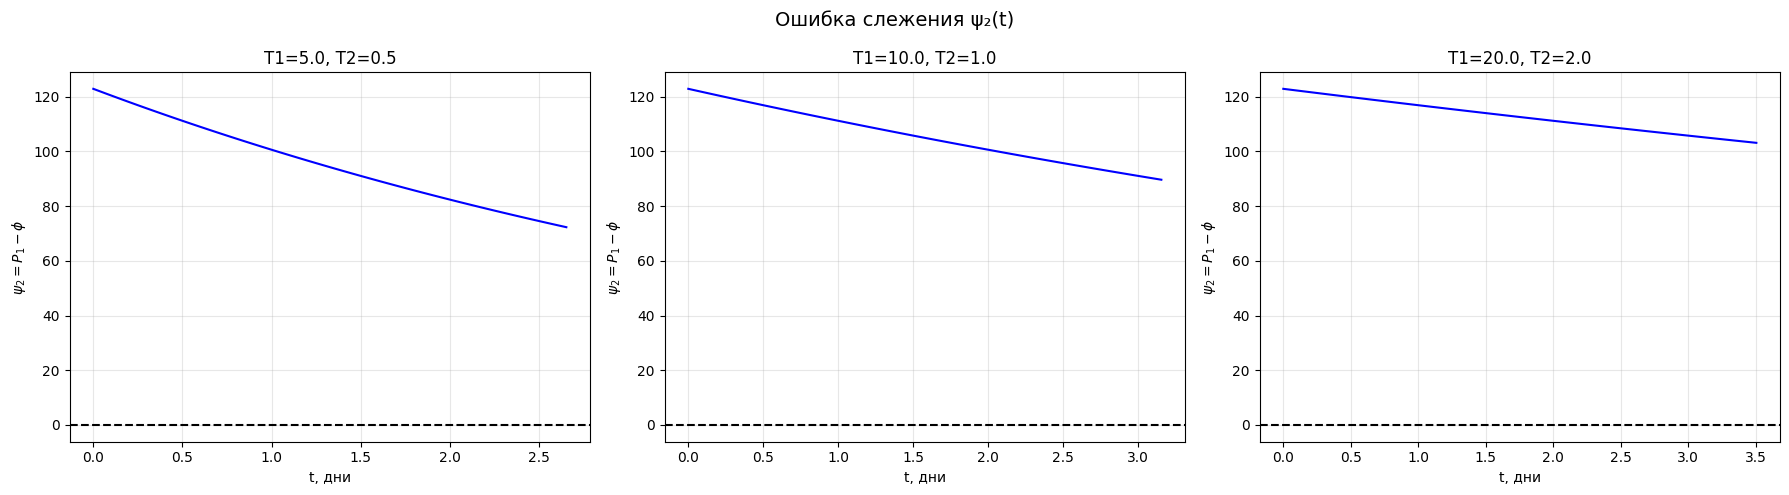

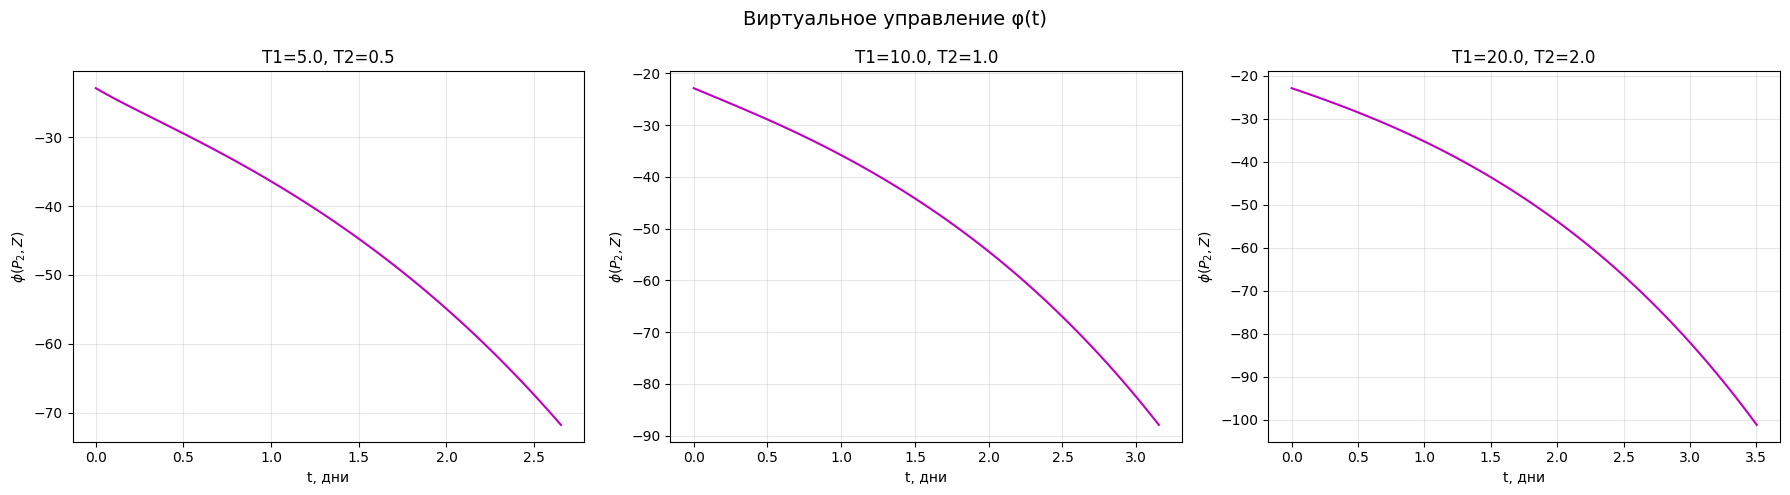

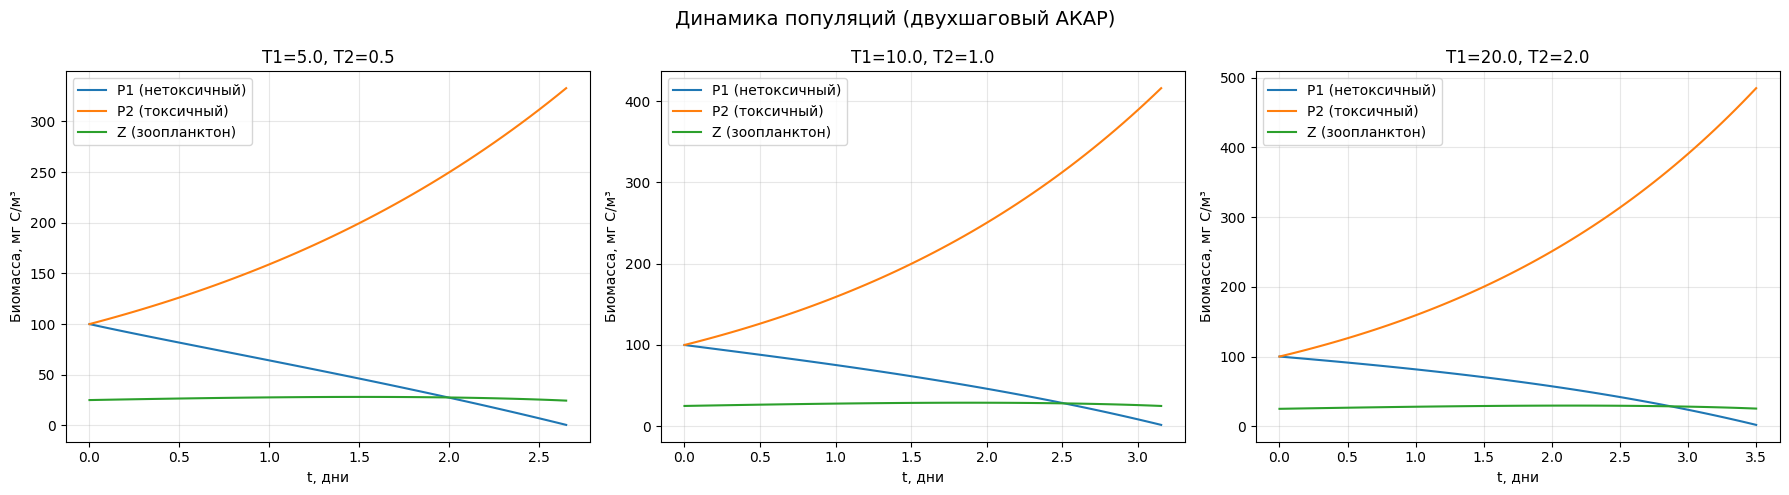

In [384]:
fig, axes = plt.subplots(1, len(T_pairs), figsize=(6*len(T_pairs), 5))
if len(T_pairs) == 1:
    axes = [axes]
fig.suptitle('Ошибка слежения ψ₂(t)', fontsize=14)

for idx, (T1,T2) in enumerate(T_pairs):
    ax = axes[idx]
    ax.plot(results[(T1,T2)].t, psi2_history[(T1,T2)], 'b-', linewidth=1.5)
    ax.axhline(0, linestyle='--', color='k')
    ax.set_xlabel('t, дни')
    ax.set_ylabel(r'$\psi_2 = P_1 - \phi$')
    ax.set_title(f'T1={T1}, T2={T2}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# управление φ(t)

fig, axes = plt.subplots(1, len(T_pairs), figsize=(6*len(T_pairs), 5))
if len(T_pairs) == 1:
    axes = [axes]
fig.suptitle('Виртуальное управление φ(t)', fontsize=14)

for idx, (T1,T2) in enumerate(T_pairs):
    ax = axes[idx]
    ax.plot(results[(T1,T2)].t, phi_history[(T1,T2)], 'm-', linewidth=1.5)
    ax.set_xlabel('t, дни')
    ax.set_ylabel(r'$\phi(P_2,Z)$')
    ax.set_title(f'T1={T1}, T2={T2}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Динамика популяций

fig, axes = plt.subplots(1, len(T_pairs), figsize=(6*len(T_pairs), 5))
if len(T_pairs) == 1:
    axes = [axes]
fig.suptitle('Динамика популяций (двухшаговый АКАР)', fontsize=14)

for idx, (T1,T2) in enumerate(T_pairs):
    ax = axes[idx]
    sol = results[(T1,T2)]
    ax.plot(sol.t, sol.y[0], label='P1 (нетоксичный)')
    ax.plot(sol.t, sol.y[1], label='P2 (токсичный)')
    ax.plot(sol.t, sol.y[2], label='Z (зоопланктон)')
    ax.set_xlabel('t, дни')
    ax.set_ylabel('Биомасса, мг C/м³')
    ax.set_title(f'T1={T1}, T2={T2}')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Вывод
Для выбранной модели, параметров и закона управления система не выходит на требуемый режим слежения. В исследованном диапазоне параметров двухшаговое управление не обеспечивает сходимость ошибки слежения к нулю.
### Анализ устойчивости двухшагового АКАР

Для всех исследованных значений параметров T1 и T2 устойчивой сходимости добиться не удалось.

По результатам моделирования установлено:

1. Биомасса токсичного фитопланктона P2 не приближается к целевому уровню $P_2^*=100$ мг С/м³, а продолжает возрастать до значений порядка 300–500 мг С/м³.

2. Вспомогательная макропеременная ψ2 = P1 − φ не стремится к нулю. Ее абсолютное значение остается порядка 100 на всем интервале моделирования.

3. Функция φ принимает отрицательные значения, что не имеет биологического смысла, поскольку биомасса фитопланктона не может быть отрицательной.

4. В результате управление стремится перевести P1 к отрицательным значениям, что приводит к выходу траектории из физически допустимой области и остановке интегрирования при возникновении отрицательной биомассы.

Таким образом, хотя закон управления был формально получен по алгоритму двухшагового АКАР, выбранная поверхность φ оказывается невозможной, а условие P1≈φ не выполняется. Из-за этого внешний контур управления по переменной P2 не реализуется и замкнутая система демонстрирует неустойчивое поведение.

Причина неустойчивости состоит не просто в "неудачных параметрах", а в том, что для выбранной цели $P_2^∗$ и принятых параметров модели требуемая виртуальная поверхность $\varphi$ оказывается отрицательной. Это означает, что через управление P1 система не обладает достаточным влиянием на динамику P2, чтобы обеспечить требуемое снижение токсичного фитопланктона